# Verification

In [1]:
from pathlib import Path
from typing import List

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

from Rotor import Rotor
import multi_rotor_analysis
import plotting_routines
from globals import main_dir, data_dir, verif_dir, res_dir, plot_dir

print(main_dir)

d:\OneDrive - Delft University of Technology\04 Fourth Year\AE4135 - Rotor Wake Aerodynamics\RWA_assignments\1_BEM


In [2]:
# Defining propeller geometry
c_R_func  = lambda r_R : 0.18-0.06*r_R
twst_func = lambda r_R : -50*r_R+35
B = 6
pitch = 46
r_R_H = 0.25
n_elem = 100
polar_path = data_dir.joinpath('ARAD8pct_polar.txt')
dist_elem = "uniform"
R = 0.7
J = 1.2
Vinf = 60 # m/s
n = Vinf/(J*2*R) # rps
rho = 1.00649 # kg/m3 (2000m ISA)
Omega = n*np.pi*2  # convert to rad/s

## Comparing against Ning

In [3]:
from juliacall import Main as jl

jl.seval("using CCBlade")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [4]:
# Our code
my_rotor = Rotor(
    c_R_func=c_R_func,
    twst_func=twst_func,
    pitch=pitch,
    B=B,
    J=J,
    R=R,
    Vinf=Vinf,
    rho=rho,
    r_R_H=r_R_H,
    n_elem=n_elem,
    polar_path=polar_path,
    dist_elem='uniform',
    isPropeller=True)

print(
f"Thrust: {my_rotor.T:.2F} [N]\n\
Azimuthal: {my_rotor.A:.2F} [N]\n\
Torque: {my_rotor.Q:.2F} [Nm] \n\
Power: {my_rotor.P:.2F} [W]")

Thrust: 2161.61 [N]
Azimuthal: 1745.50 [N]
Torque: 810.92 [Nm] 
Power: 485063.49 [W]


In [5]:
# Ning code
Rhub = r_R_H*R
Rtip = R   

rotor = jl.Rotor(Rhub, Rtip, B)

r_R_lst = np.linspace(r_R_H, 1, n_elem)
r = r_R_lst * Rtip
chord = c_R_func(r_R_lst)* Rtip
theta = np.deg2rad(twst_func(r_R_lst))

# af = jl.seval(f'AlphaAF("data/ARAD8pct_polar_ningfmt.txt")')
af = jl.seval('AlphaAF("data/ARAD8pct_polar_ningfmt.txt"; radians=false)')
sections = jl.broadcast(jl.Section, r, chord, theta, jl.Ref(af))

jl.seval("""
function simple_op_pitch(Vinf, Omega, r, rho, pitch)
    return simple_op(Vinf, Omega, r, rho; pitch=pitch)
end
""")

op = jl.broadcast(jl.simple_op_pitch, Vinf, Omega, r, rho, float(np.deg2rad(pitch)))

out = jl.broadcast(jl.solve, jl.Ref(rotor), sections, op)

T, Q = jl.thrusttorque(rotor, sections, out)

print(f"Thrust: {T} [N]\nTorque: {Q} [Nm]")

Thrust: 2162.9938414123844 [N]
Torque: 811.4334756870406 [Nm]


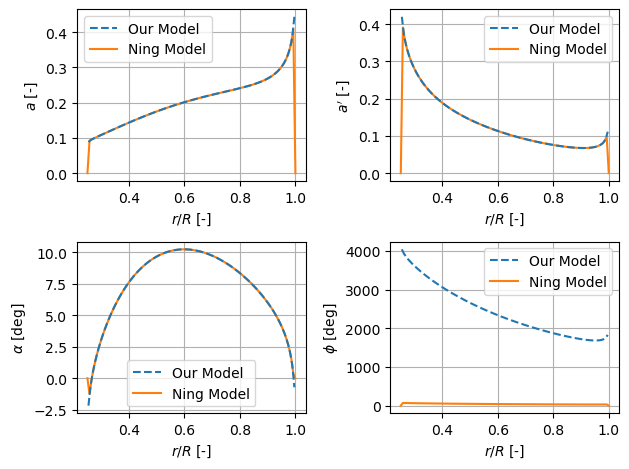

In [6]:
axs: List[Axes]
fig, axs = plt.subplots(2, 2)

ax = axs[0,0]
ax.plot(my_rotor.r_R, my_rotor.a, ls='--', label="Our Model", zorder=3)
ax.plot(r_R_lst, out.a, label="Ning Model")
ax.grid()
ax.legend()
ax.set_ylabel(r"$a$ [-]")
ax.set_xlabel(r"$r/R$ [-]")

ax = axs[0,1]
ax.plot(my_rotor.r_R, my_rotor.aline, ls='--', label="Our Model", zorder=3)
ax.plot(r_R_lst, out.ap, label="Ning Model")
ax.grid()
ax.legend()
ax.set_ylabel(r"$a'$ [-]")
ax.set_xlabel(r"$r/R$ [-]")


ax = axs[1,0]
ax.plot(my_rotor.r_R, my_rotor.alpha, ls='--', label="Our Model", zorder=3)
ax.plot(r_R_lst, np.rad2deg(out.alpha), label="Ning Model")
ax.grid()
ax.legend()
ax.set_ylabel(r"$\alpha$ [deg]")
ax.set_xlabel(r"$r/R$ [-]")


ax = axs[1,1]
ax.plot(my_rotor.r_R, np.rad2deg(my_rotor.phi), ls='--', label="Our Model", zorder=3)
ax.plot(r_R_lst, np.rad2deg(out.phi), label="Ning Model")
ax.grid()
ax.legend()
ax.set_ylabel(r"$\phi$ [deg]")
ax.set_xlabel(r"$r/R$ [-]")
fig.tight_layout()

fig.savefig(plot_dir.joinpath('verif_Ning.pdf'))

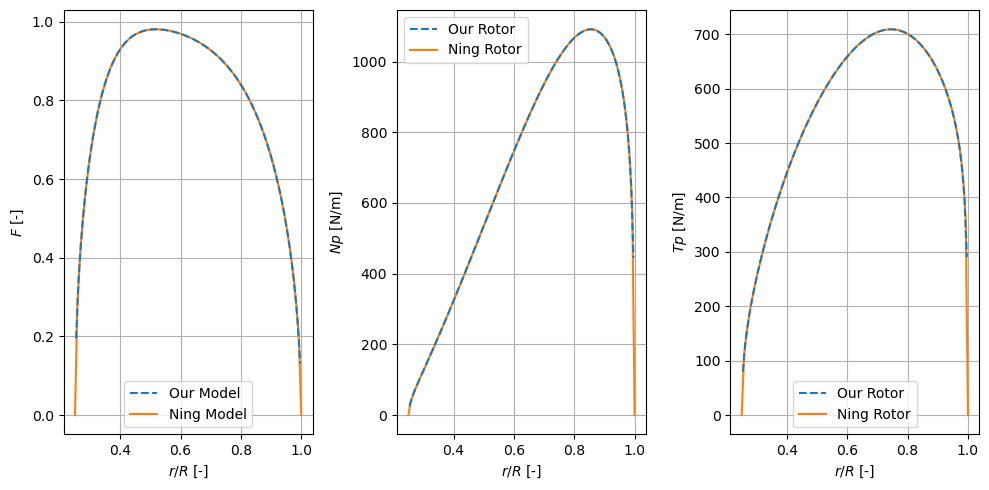

In [7]:
axs: List[Axes]
fig, axs = plt.subplots(1, 3, figsize=(10,5))

ax = axs[0]
ax.plot(my_rotor.r_R, my_rotor.f, ls='--', label="Our Model", zorder=3)
ax.plot(r_R_lst, out.F, label="Ning Model")
ax.grid()
ax.legend()
ax.set_ylabel(r"$F$ [-]")
ax.set_xlabel(r"$r/R$ [-]")

ax = axs[1]
ax.plot(my_rotor.r_R, my_rotor.Np, ls='--', label="Our Rotor", zorder=3)
ax.plot(r_R_lst, out.Np, label="Ning Rotor")
ax.grid()
ax.legend()
ax.set_ylabel(r"$Np$ [N/m]")
ax.set_xlabel(r"$r/R$ [-]")

ax = axs[2]
ax.plot(my_rotor.r_R, my_rotor.Tp, ls='--', label="Our Rotor", zorder=3)
ax.plot(r_R_lst, out.Tp, label="Ning Rotor")
ax.grid()
ax.legend()
ax.set_ylabel(r"$Tp$ [N/m]")
ax.set_xlabel(r"$r/R$ [-]")

fig.tight_layout()

## Comparing Against JavaProp

In [8]:
multi_rotor_analysis.run('J', 'ARAD6', 'results',
                         polar_name='ARAD6pct_polar.txt') # default values suffice

df = pd.read_csv(res_dir.joinpath('results_J_ARAD6.csv'))

In [9]:
#Java Prop validation data for whole propeller
csv_file_path = verif_dir.joinpath('JavaPropValMulti.csv')
dfs = pd.read_csv(csv_file_path, sep=r"\s+")
dfs = dfs.drop([0]) #drop the second row
dfs = dfs.rename(columns={'v/(nD)': 'J', 'v':'V','?':'eta', '?*':'eta*', "Ct":"CT", "Cp":"CP"}) #rename columns
dfs = dfs.drop(columns=["v/(?R)","Cs","eta*","stalled"]) #drop
dfs = dfs.astype(float) #convert all columns to float
dfs = dfs[dfs['J'] > 1.2]
dfs['CQ'] = dfs['Torque'] / dfs['Thrust'] * dfs['CT']/(2*R)  # Convert to kN-m
dfs['eta'] = dfs['eta']/100
dfJavawhole = dfs

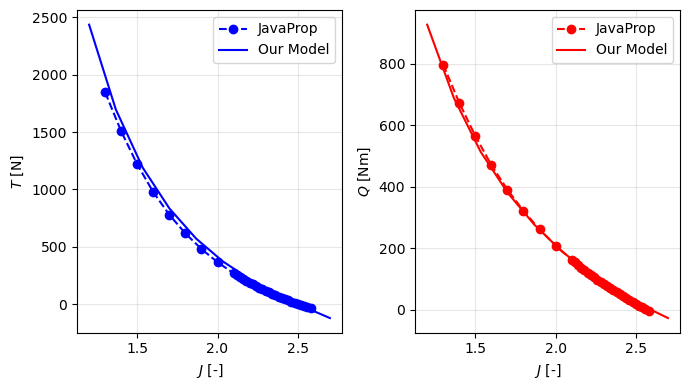

In [10]:
fig, axs = plt.subplots(1,2, figsize=(7,4))

javaprop_style = {
    'data_df': dfJavawhole,
    'verif': True,
    'ls': '--',
    'marker': 'o',
    'label': 'JavaProp',
}

ourcode_style = {
    'data_df': df,
    'verif': False,
    'ls': '-',
    'label': 'Our Model',
}
# Thrust Plot
plotting_routines.forces(plot_vs='J',
                         plot_ag= 'T',
                         color='blue',
                         ax=axs[0],
                         **javaprop_style,
                         )
plotting_routines.forces(plot_vs='J',
                         plot_ag= 'T',
                         color='blue',
                         ax=axs[0],
                         **ourcode_style,
                         )

# Torque Plot
plotting_routines.forces(plot_vs='J',
                         plot_ag= 'Q',
                         color='red',
                         ax=axs[1],
                         **javaprop_style,
                         )
plotting_routines.forces(plot_vs='J',
                         plot_ag='Q',
                         color='red',
                         ax=axs[1],
                         **ourcode_style,
                         )


axs[0].legend(loc="upper right")
axs[1].legend(loc="upper right")
fig.tight_layout()

fig.savefig(plot_dir.joinpath("verif_javaprop.pdf"))